In [4]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import importlib
import astropy.units as u
import astropy.constants as c

import sys
sys.path.append('/global/homes/c/cpopik/CAPPIBARAS')

import Plots, SHMRs
import Models.Studies as Studies

# Plot Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
    # 'figure.figsize': [9, 6], 'axes.titlesize':15, 'legend.fontsize': 5, 'legend.title_fontsize': 10,
    # 'axes.labelsize':15, 'xtick.labelsize':15, 'ytick.labelsize':15
})

# Checked

## Kravstov 2018

Om0 0.27 0.27 0.27 adsa
Ob0 0.0469 0.0469 0.0469 adsa
h 0.7 0.7 0.7 adsa
sigma8 0.82 0.82 0.82 adsa
ns 0.95 0.95 0.95 adsa
logM1 {'B': {'200c': 11.39, '500c': 11.32, '200m': 11.45, 'vir': 11.43}, 'S': {'200c': 11.35, '500c': 11.28, '200m': 11.41, 'vir': 11.39}} 11.35 11.35 adsa
logeps {'B': {'200c': -1.618, '500c': -1.527, '200m': -1.702, 'vir': -1.663}, 'S': {'200c': -1.642, '500c': -1.556, '200m': -1.72, 'vir': -1.685}} -1.642 -1.642 adsa
alpha {'B': {'200c': 1.795, '500c': 1.856, '200m': 1.736, 'vir': 1.75}, 'S': {'200c': 1.779, '500c': 1.835, '200m': 1.727, 'vir': 1.74}} 1.779 1.779 adsa
delta {'B': {'200c': 4.345, '500c': 4.376, '200m': 4.273, 'vir': 4.29}, 'S': {'200c': 4.394, '500c': 4.437, '200m': 4.305, 'vir': 4.335}} 4.394 4.394 adsa
gamma {'B': {'200c': 0.619, '500c': 0.644, '200m': 0.613, 'vir': 0.595}, 'S': {'200c': 0.547, '500c': 0.567, '200m': 0.544, 'vir': 0.531}} 0.547 0.547 adsa
slope {'BCG': {'K18': 0.39, 'K18G13': 0.33}, 'sat': {'K18': 0.87, 'K18G13': 0.75}, 'tot': 

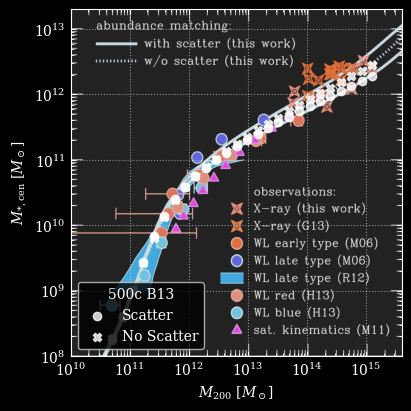

In [38]:
importlib.reload(Plots); importlib.reload(Studies); importlib.reload(SHMRs)
fig, ax = Plots.Kravtsov2018().Fig10(width=4, height=4)

logMh = np.linspace(10, 15.1, 30)

K18 = SHMRs.Kravtsov2018({'mdef':'200c', 'scatter':'S', 'model':'B13'})
ax.scatter(10**logMh, 10**K18.SHMR(logMh)(), alpha=0.8, c='w', label='Scatter')

K18 = SHMRs.Kravtsov2018({'mdef':'200c', 'scatter':'B', 'model':'B13'})
ax.scatter(10**logMh, 10**K18.SHMR(logMh)(), alpha=0.8, marker='X', c='w', label='No Scatter')

ax.legend(loc='lower left', title='500c B13', fontsize=10)
plt.show()

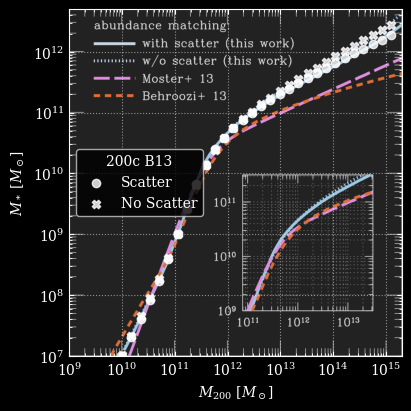

In [4]:
importlib.reload(Plots); importlib.reload(SHMRs)
fig, ax = Plots.Kravtsov2018().Fig17(width=4, height=4)

logMh = np.linspace(10, 15.1, 30)

K18 = SHMRs.Kravtsov2018({'mdef':'200c', 'scatter':'S', 'model':'B13'})
ax.scatter(10**logMh, 10**K18.SHMR(logMh)(), alpha=0.8, c='w', label='Scatter')

K18 = SHMRs.Kravtsov2018({'mdef':'200c', 'scatter':'B', 'model':'B13'})
ax.scatter(10**logMh, 10**K18.SHMR(logMh)(), alpha=0.8, marker='X', c='w', label='No Scatter')

ax.legend(loc='center left', title='200c B13')
plt.show()

## Gao 2023

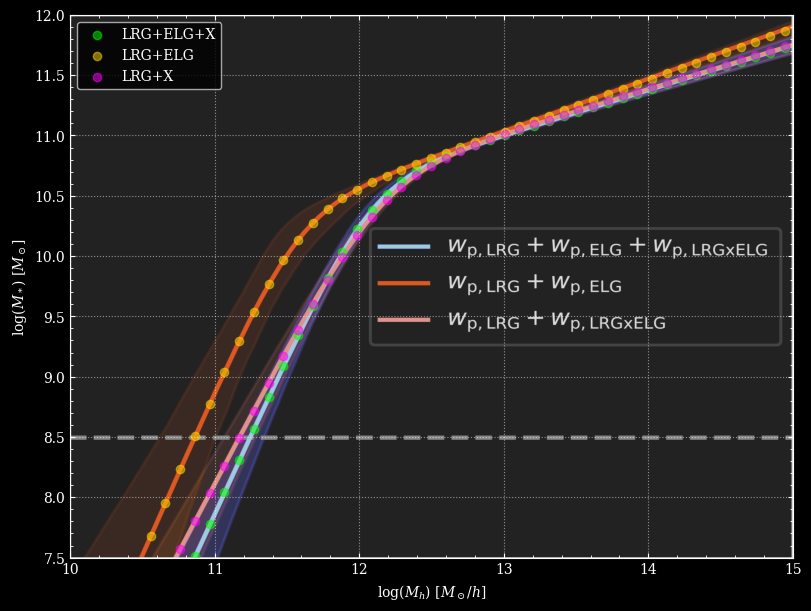

In [11]:
importlib.reload(Plots); importlib.reload(SHMRs)
fig, ax = Plots.Gao2023().Fig7a()

logMh = np.linspace(10, 15, 50)
logMhh = np.log10(10**logMh/SHMRs.Gao2023().h)
ax.scatter(logMhh, SHMRs.Gao2023({'model':'Psat'}).SHMR(logMh)(), alpha=0.5, c='lime', label='LRG+ELG+X')
ax.scatter(logMhh, SHMRs.Gao2023({'model':'Auto'}).SHMR(logMh)(), alpha=0.5, c='gold', label='LRG+ELG')
ax.scatter(logMhh, SHMRs.Gao2023({'model':'Cross'}).SHMR(logMh)(), alpha=0.5, c='magenta', label='LRG+X')

ax.legend()
plt.show()

# Xu 2023

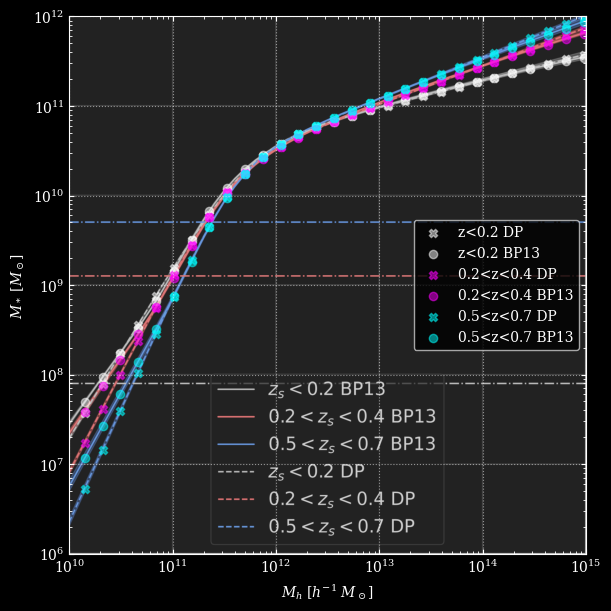

In [12]:
importlib.reload(Plots); importlib.reload(SHMRs)
fig, ax = Plots.Xu2023().Fig7()

logMh = np.linspace(10, 15, 30)
Mhsh = 10**logMh/SHMRs.Xu2023().h

ax.scatter(Mhsh, 10**SHMRs.Xu2023(form='DP', sample='Main').SHMR(logMh)(), marker='X', alpha=0.5, c='w', label='z<0.2 DP')
ax.scatter(Mhsh, 10**SHMRs.Xu2023(form='BP13', sample='Main').SHMR(logMh)(), alpha=0.5, c='w', label='z<0.2 BP13')
ax.scatter(Mhsh, 10**SHMRs.Xu2023(form='DP', sample='LOWZ').SHMR(logMh)(), marker='X', alpha=0.5, c='magenta', label='0.2<z<0.4 DP')
ax.scatter(Mhsh, 10**SHMRs.Xu2023(form='BP13', sample='LOWZ').SHMR(logMh)(), alpha=0.5, c='magenta', label='0.2<z<0.4 BP13')
ax.scatter(Mhsh, 10**SHMRs.Xu2023(form='DP', sample='CMASS').SHMR(logMh)(), marker='X', alpha=0.5, c='cyan', label='0.5<z<0.7 DP')
ax.scatter(Mhsh, 10**SHMRs.Xu2023(form='BP13', sample='CMASS').SHMR(logMh)(), alpha=0.5, c='cyan', label='0.5<z<0.7 BP13')

ax.legend(loc='center right')
plt.show()

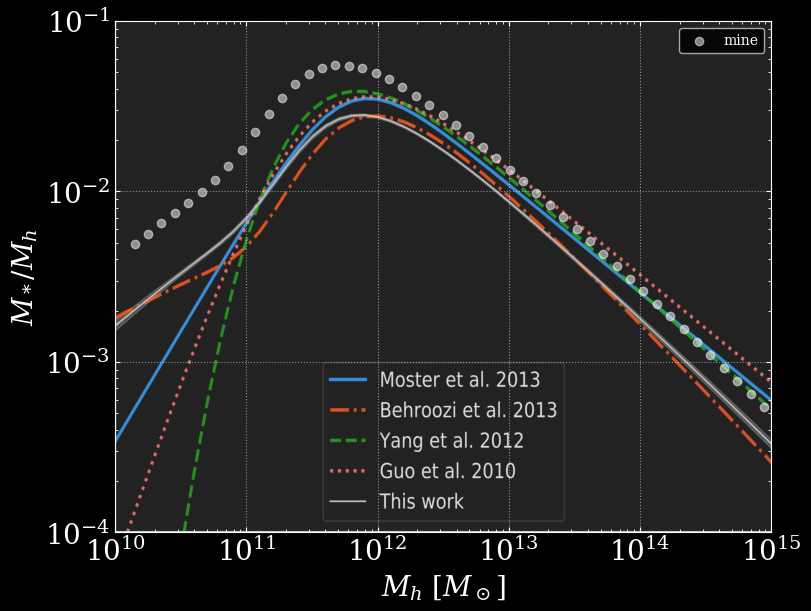

In [12]:
importlib.reload(Plots); importlib.reload(SHMRs)
fig, ax = Plots.Xu2023().Fig9()

logMh = np.linspace(10, 15, 50)
Mhsh = 10**logMh/SHMRs.Xu2023().h

Xu2023 = SHMRs.Xu2023({'sample':'Main', 'form':'BP13'})
ax.scatter(Mhsh, 10**Xu2023.SHMR(logMh)()/(10**logMh), alpha=0.5, c='w', label='mine')
# ax.scatter(Mhsh, 10**Xu2023.SHMR(logMh+np.log10(Xu2023.h))()/(10**logMh/Xu2023.h), alpha=0.5, c='cyan', label='mine')
# ax.scatter(10**logMh, 10**Xu2023.SHMR(logMh+np.log10(Xu2023.h))()/(10**logMh/Xu2023.h), alpha=0.5, c='lime', label='mine')

ax.legend()
plt.show()

# All

In [ ]:
importlib.reload(SHMRs)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
axs[0].set(xlabel=r'$M_h \ [M_\odot]$', ylabel=r'$M_\star / M_h$')
axs[1].set(xlabel=r'$M_h \ [M_\odot]$', ylabel=r'$M_\star \ [M_\odot]$')

logMh, logMs = np.linspace(10, 15, 50), np.linspace(7, 12, 25)
def plot(model, name):
    axs[0].loglog(10**logMh, 10**model.SHMR(logMh)()/10**logMh, label=name)
    axs[1].loglog(10**logMh, 10**model.SHMR(logMh)(), label=name)
    axs[0].scatter(10**model.HSMR(logMs)(), 10**logMs/10**model.HSMR(logMs)())
    axs[1].scatter(10**model.HSMR(logMs)(), 10**logMs)

plot(SHMRs.Xu2023(sample='CMASS', form='BP13'), 'CMASS DR12')
plot(SHMRs.Gao2023(model='Cross'), 'DESI 1P')
plot(SHMRs.Kravstov2018(model='B13',mdef='vir', scatter='S'), 'SDSS DR8')

for ax in axs.flatten(): ax.legend()
plt.show()